# Neural Networks from Scratch in NumPy for 3-Class Classification

This notebook is a classification-focused version of the NumPy neural network code used for regression.

The main changes are:

- The target variable has **three classes** instead of continuous real-valued outputs.
- The output layer uses **softmax** probabilities.
- The loss function is **cross-entropy loss** instead of mean squared error.
- Model quality is measured using **classification accuracy**.

We will implement and compare:

1. A **single-layer classifier**, also called multinomial logistic regression.
2. A **two-layer neural network classifier**, with one hidden layer.
3. A **three-layer neural network classifier**, with two hidden layers.

## 1. Imports and Data Generation

We generate a small synthetic data set with three classes in two dimensions.

Each column of `X` is one data point, so the input data has shape

$$X \in \mathbb{R}^{2 \times m}.$$

The labels are stored as integers `0`, `1`, or `2`, and we also create a one-hot encoded label matrix

$$ Y \in \mathbb{R}^{3 \times m}. $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Number of observations per class
m_per_class = 100
num_classes = 3
m = m_per_class * num_classes

# Input dimension
n_in = 2

# Generate 3 Gaussian clusters in R^2
means = np.array([
    [-2.0, -1.0],
    [ 2.0, -1.0],
    [ 0.0,  2.0]
])

X_list = []
y_list = []

for k in range(num_classes):
    Xk = means[k] + 0.85 * np.random.randn(m_per_class, n_in)
    yk = k * np.ones(m_per_class, dtype=int)
    X_list.append(Xk)
    y_list.append(yk)

X_raw = np.vstack(X_list)      # shape: [m, 2]
y = np.concatenate(y_list)    # shape: [m]

# Shuffle the data
perm = np.random.permutation(m)
X_raw = X_raw[perm]
y = y[perm]

# Store X as [n_in, m], matching the style of the regression code
X = X_raw.T

# One-hot encoding: Y has shape [num_classes, m]
Y = np.zeros((num_classes, m))
Y[y, np.arange(m)] = 1

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("y shape:", y.shape)

X shape: (2, 300)
Y shape: (3, 300)
y shape: (300,)


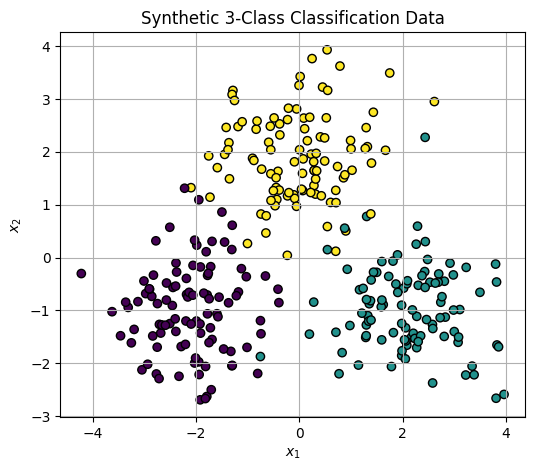

In [2]:
plt.figure(figsize=(6, 5))
plt.scatter(X[0, :], X[1, :], c=y, edgecolor='k')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Synthetic 3-Class Classification Data')
plt.grid(True)
plt.show()

## 2. Helper Functions

For classification, the output layer will use the softmax function.

For one sample with score vector $(z \in \mathbb{R}^3)$, softmax is

$$
\operatorname{softmax}(z)_k = \frac{e^{z_k}}{\sum_{j=1}^3 e^{z_j}}.
$$

The softmax output can be interpreted as class probabilities.

We train using cross-entropy loss:

$$
L = -\frac{1}{m}\sum_{i=1}^m \sum_{k=1}^3 y_k^{(i)} \log\left(\hat{y}_k^{(i)}\right).
$$

When softmax is combined with cross-entropy, the output layer derivative simplifies to

$$
\frac{\partial L}{\partial Z} = \hat{Y} - Y.
$$

In [ ]:
def one_hot_to_labels(Y):
    return np.argmax(Y, axis=0)


def softmax(Z):
    # Stable softmax: subtract max value in each column
    Z_shifted = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)


def compute_cross_entropy_loss(Yhat, Y):
    # Yhat and Y both have shape [num_classes, batch_size]
    eps = 1e-12
    m_batch = Y.shape[1]
    return -np.sum(Y * np.log(Yhat + eps)) / m_batch


def compute_accuracy(Yhat, y_true):
    y_pred = np.argmax(Yhat, axis=0)
    return np.mean(y_pred == y_true)


def apply_activation(Z, activation_name):
    name = activation_name.lower()

    if name == 'sigmoid':
        return 1 / (1 + np.exp(-Z))
    elif name == 'tanh':
        return np.tanh(Z)
    elif name == 'relu':
        return np.maximum(0, Z)
    elif name == 'linear':
        return Z
    else:
        raise ValueError(f'Unknown activation: {activation_name}')


def activation_derivative_from_z(Z, activation_name):
    name = activation_name.lower()

    if name == 'sigmoid':
        S = 1 / (1 + np.exp(-Z))
        return S * (1 - S)
    elif name == 'tanh':
        T = np.tanh(Z)
        return 1 - T**2
    elif name == 'relu':
        return (Z > 0).astype(float)
    elif name == 'linear':
        return np.ones_like(Z)
    else:
        raise ValueError(f'Unknown activation: {activation_name}')

## 3. Single-Layer Neural Network Classifier

A single-layer classifier has no hidden layer. It maps the input directly to class scores:

\[
Z_1 = W_1X + b_1,
\]

then converts scores to probabilities using softmax:

\[
A_1 = \operatorname{softmax}(Z_1).
\]

This model is equivalent to multinomial logistic regression.

In [ ]:
def initialize_single_layer_parameters(layer_sizes):
    n_in = layer_sizes['input']
    n_out = layer_sizes['output']

    limit = np.sqrt(6 / (n_in + n_out))

    params = {}
    params['W1'] = -limit + 2 * limit * np.random.rand(n_out, n_in)
    params['b1'] = np.zeros((n_out, 1))

    return params


def forward_single_layer(X, params):
    Z1 = params['W1'] @ X + params['b1']
    A1 = softmax(Z1)

    cache = {
        'Z1': Z1,
        'A1': A1
    }

    return cache


def backward_single_layer(X, Y, params, cache):
    m_batch = X.shape[1]

    # Softmax + cross-entropy derivative
    dZ1 = cache['A1'] - Y

    grads = {}
    grads['dW1'] = (1 / m_batch) * (dZ1 @ X.T)
    grads['db1'] = (1 / m_batch) * np.sum(dZ1, axis=1, keepdims=True)

    return grads


def train_single_layer_classifier(X, Y, layer_sizes, opts):
    n_in, m = X.shape
    n_out, mY = Y.shape

    if m != mY:
        raise ValueError('X and Y must have the same number of samples.')

    if layer_sizes['input'] != n_in:
        raise ValueError('layer_sizes.input must match size(X,1).')

    if layer_sizes['output'] != n_out:
        raise ValueError('layer_sizes.output must match size(Y,1).')

    if 'seed' in opts:
        np.random.seed(opts['seed'])

    params = initialize_single_layer_parameters(layer_sizes)

    history = {}
    history['loss'] = np.zeros((opts['epochs'],))
    history['accuracy'] = np.zeros((opts['epochs'],))

    y_labels = one_hot_to_labels(Y)

    for epoch in range(opts['epochs']):
        perm = np.random.permutation(m)
        X_shuf = X[:, perm]
        Y_shuf = Y[:, perm]

        num_batches = int(np.ceil(m / opts['batch_size']))
        epoch_loss = 0.0

        for b in range(num_batches):
            idx_start = b * opts['batch_size']
            idx_end = min((b + 1) * opts['batch_size'], m)
            batch_idx = np.arange(idx_start, idx_end)

            Xb = X_shuf[:, batch_idx]
            Yb = Y_shuf[:, batch_idx]

            cache = forward_single_layer(Xb, params)
            batch_loss = compute_cross_entropy_loss(cache['A1'], Yb)
            epoch_loss += batch_loss

            grads = backward_single_layer(Xb, Yb, params, cache)

            params['W1'] -= opts['learning_rate'] * grads['dW1']
            params['b1'] -= opts['learning_rate'] * grads['db1']

        full_cache = forward_single_layer(X, params)
        history['loss'][epoch] = epoch_loss / num_batches
        history['accuracy'][epoch] = compute_accuracy(full_cache['A1'], y_labels)

        if opts['verbose'] and (((epoch + 1) % max(1, opts['epochs'] // 10) == 0) or (epoch == 0)):
            print(f"Epoch {epoch + 1}/{opts['epochs']}, Loss = {history['loss'][epoch]:.6f}, Accuracy = {history['accuracy'][epoch]:.4f}")

    return params, history


def predict_single_layer_classifier(X, params):
    cache = forward_single_layer(X, params)
    Yhat = cache['A1']
    y_pred = np.argmax(Yhat, axis=0)
    return Yhat, y_pred

## 4. Two-Layer Neural Network Classifier

A two-layer network has one hidden layer:

\[
Z_1 = W_1X + b_1,
\]

\[
A_1 = \sigma(Z_1),
\]

\[
Z_2 = W_2A_1 + b_2,
\]

\[
A_2 = \operatorname{softmax}(Z_2).
\]

Here \(\sigma\) can be `tanh`, `sigmoid`, or `relu`.

In [ ]:
def initialize_two_layer_parameters(layer_sizes):
    n_in = layer_sizes['input']
    n_h = layer_sizes['hidden']
    n_out = layer_sizes['output']

    limit1 = np.sqrt(6 / (n_in + n_h))
    limit2 = np.sqrt(6 / (n_h + n_out))

    params = {}
    params['W1'] = -limit1 + 2 * limit1 * np.random.rand(n_h, n_in)
    params['b1'] = np.zeros((n_h, 1))
    params['W2'] = -limit2 + 2 * limit2 * np.random.rand(n_out, n_h)
    params['b2'] = np.zeros((n_out, 1))

    return params


def forward_two_layer(X, params, activations):
    Z1 = params['W1'] @ X + params['b1']
    A1 = apply_activation(Z1, activations['hidden'])

    Z2 = params['W2'] @ A1 + params['b2']
    A2 = softmax(Z2)

    cache = {
        'Z1': Z1,
        'A1': A1,
        'Z2': Z2,
        'A2': A2
    }

    return cache


def backward_two_layer(X, Y, params, cache, activations):
    m_batch = X.shape[1]

    # Softmax + cross-entropy derivative
    dZ2 = cache['A2'] - Y

    grads = {}
    grads['dW2'] = (1 / m_batch) * (dZ2 @ cache['A1'].T)
    grads['db2'] = (1 / m_batch) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = params['W2'].T @ dZ2
    dZ1 = dA1 * activation_derivative_from_z(cache['Z1'], activations['hidden'])

    grads['dW1'] = (1 / m_batch) * (dZ1 @ X.T)
    grads['db1'] = (1 / m_batch) * np.sum(dZ1, axis=1, keepdims=True)

    return grads


def train_two_layer_classifier(X, Y, layer_sizes, activations, opts):
    n_in, m = X.shape
    n_out, mY = Y.shape

    if m != mY:
        raise ValueError('X and Y must have the same number of samples.')

    if layer_sizes['input'] != n_in:
        raise ValueError('layer_sizes.input must match size(X,1).')

    if layer_sizes['output'] != n_out:
        raise ValueError('layer_sizes.output must match size(Y,1).')

    if 'seed' in opts:
        np.random.seed(opts['seed'])

    params = initialize_two_layer_parameters(layer_sizes)

    history = {}
    history['loss'] = np.zeros((opts['epochs'],))
    history['accuracy'] = np.zeros((opts['epochs'],))

    y_labels = one_hot_to_labels(Y)

    for epoch in range(opts['epochs']):
        perm = np.random.permutation(m)
        X_shuf = X[:, perm]
        Y_shuf = Y[:, perm]

        num_batches = int(np.ceil(m / opts['batch_size']))
        epoch_loss = 0.0

        for b in range(num_batches):
            idx_start = b * opts['batch_size']
            idx_end = min((b + 1) * opts['batch_size'], m)
            batch_idx = np.arange(idx_start, idx_end)

            Xb = X_shuf[:, batch_idx]
            Yb = Y_shuf[:, batch_idx]

            cache = forward_two_layer(Xb, params, activations)
            batch_loss = compute_cross_entropy_loss(cache['A2'], Yb)
            epoch_loss += batch_loss

            grads = backward_two_layer(Xb, Yb, params, cache, activations)

            params['W1'] -= opts['learning_rate'] * grads['dW1']
            params['b1'] -= opts['learning_rate'] * grads['db1']
            params['W2'] -= opts['learning_rate'] * grads['dW2']
            params['b2'] -= opts['learning_rate'] * grads['db2']

        full_cache = forward_two_layer(X, params, activations)
        history['loss'][epoch] = epoch_loss / num_batches
        history['accuracy'][epoch] = compute_accuracy(full_cache['A2'], y_labels)

        if opts['verbose'] and (((epoch + 1) % max(1, opts['epochs'] // 10) == 0) or (epoch == 0)):
            print(f"Epoch {epoch + 1}/{opts['epochs']}, Loss = {history['loss'][epoch]:.6f}, Accuracy = {history['accuracy'][epoch]:.4f}")

    return params, history


def predict_two_layer_classifier(X, params, activations):
    cache = forward_two_layer(X, params, activations)
    Yhat = cache['A2']
    y_pred = np.argmax(Yhat, axis=0)
    return Yhat, y_pred

## 5. Three-Layer Neural Network Classifier

A three-layer network has two hidden layers:

\[
Z_1 = W_1X + b_1, \quad A_1 = \sigma_1(Z_1),
\]

\[
Z_2 = W_2A_1 + b_2, \quad A_2 = \sigma_2(Z_2),
\]

\[
Z_3 = W_3A_2 + b_3, \quad A_3 = \operatorname{softmax}(Z_3).
\]

The final output \(A_3\) contains the predicted class probabilities.

In [ ]:
def initialize_three_layer_parameters(layer_sizes):
    n_in = layer_sizes['input']
    n_h1 = layer_sizes['hidden1']
    n_h2 = layer_sizes['hidden2']
    n_out = layer_sizes['output']

    limit1 = np.sqrt(6 / (n_in + n_h1))
    limit2 = np.sqrt(6 / (n_h1 + n_h2))
    limit3 = np.sqrt(6 / (n_h2 + n_out))

    params = {}
    params['W1'] = -limit1 + 2 * limit1 * np.random.rand(n_h1, n_in)
    params['b1'] = np.zeros((n_h1, 1))
    params['W2'] = -limit2 + 2 * limit2 * np.random.rand(n_h2, n_h1)
    params['b2'] = np.zeros((n_h2, 1))
    params['W3'] = -limit3 + 2 * limit3 * np.random.rand(n_out, n_h2)
    params['b3'] = np.zeros((n_out, 1))

    return params


def forward_three_layer(X, params, activations):
    Z1 = params['W1'] @ X + params['b1']
    A1 = apply_activation(Z1, activations['hidden1'])

    Z2 = params['W2'] @ A1 + params['b2']
    A2 = apply_activation(Z2, activations['hidden2'])

    Z3 = params['W3'] @ A2 + params['b3']
    A3 = softmax(Z3)

    cache = {
        'Z1': Z1,
        'A1': A1,
        'Z2': Z2,
        'A2': A2,
        'Z3': Z3,
        'A3': A3
    }

    return cache


def backward_three_layer(X, Y, params, cache, activations):
    m_batch = X.shape[1]

    # Softmax + cross-entropy derivative
    dZ3 = cache['A3'] - Y

    grads = {}
    grads['dW3'] = (1 / m_batch) * (dZ3 @ cache['A2'].T)
    grads['db3'] = (1 / m_batch) * np.sum(dZ3, axis=1, keepdims=True)

    dA2 = params['W3'].T @ dZ3
    dZ2 = dA2 * activation_derivative_from_z(cache['Z2'], activations['hidden2'])

    grads['dW2'] = (1 / m_batch) * (dZ2 @ cache['A1'].T)
    grads['db2'] = (1 / m_batch) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = params['W2'].T @ dZ2
    dZ1 = dA1 * activation_derivative_from_z(cache['Z1'], activations['hidden1'])

    grads['dW1'] = (1 / m_batch) * (dZ1 @ X.T)
    grads['db1'] = (1 / m_batch) * np.sum(dZ1, axis=1, keepdims=True)

    return grads


def train_three_layer_classifier(X, Y, layer_sizes, activations, opts):
    n_in, m = X.shape
    n_out, mY = Y.shape

    if m != mY:
        raise ValueError('X and Y must have the same number of samples.')

    if layer_sizes['input'] != n_in:
        raise ValueError('layer_sizes.input must match size(X,1).')

    if layer_sizes['output'] != n_out:
        raise ValueError('layer_sizes.output must match size(Y,1).')

    if 'seed' in opts:
        np.random.seed(opts['seed'])

    params = initialize_three_layer_parameters(layer_sizes)

    history = {}
    history['loss'] = np.zeros((opts['epochs'],))
    history['accuracy'] = np.zeros((opts['epochs'],))

    y_labels = one_hot_to_labels(Y)

    for epoch in range(opts['epochs']):
        perm = np.random.permutation(m)
        X_shuf = X[:, perm]
        Y_shuf = Y[:, perm]

        num_batches = int(np.ceil(m / opts['batch_size']))
        epoch_loss = 0.0

        for b in range(num_batches):
            idx_start = b * opts['batch_size']
            idx_end = min((b + 1) * opts['batch_size'], m)
            batch_idx = np.arange(idx_start, idx_end)

            Xb = X_shuf[:, batch_idx]
            Yb = Y_shuf[:, batch_idx]

            cache = forward_three_layer(Xb, params, activations)
            batch_loss = compute_cross_entropy_loss(cache['A3'], Yb)
            epoch_loss += batch_loss

            grads = backward_three_layer(Xb, Yb, params, cache, activations)

            params['W1'] -= opts['learning_rate'] * grads['dW1']
            params['b1'] -= opts['learning_rate'] * grads['db1']
            params['W2'] -= opts['learning_rate'] * grads['dW2']
            params['b2'] -= opts['learning_rate'] * grads['db2']
            params['W3'] -= opts['learning_rate'] * grads['dW3']
            params['b3'] -= opts['learning_rate'] * grads['db3']

        full_cache = forward_three_layer(X, params, activations)
        history['loss'][epoch] = epoch_loss / num_batches
        history['accuracy'][epoch] = compute_accuracy(full_cache['A3'], y_labels)

        if opts['verbose'] and (((epoch + 1) % max(1, opts['epochs'] // 10) == 0) or (epoch == 0)):
            print(f"Epoch {epoch + 1}/{opts['epochs']}, Loss = {history['loss'][epoch]:.6f}, Accuracy = {history['accuracy'][epoch]:.4f}")

    return params, history


def predict_three_layer_classifier(X, params, activations):
    cache = forward_three_layer(X, params, activations)
    Yhat = cache['A3']
    y_pred = np.argmax(Yhat, axis=0)
    return Yhat, y_pred

## 6. Train the Three Classifiers

The training setup below is intentionally close to the regression script:

- `learning_rate`
- `epochs`
- `batch_size`
- `verbose`
- `seed`

The main difference is that the classification loss is cross-entropy.

In [ ]:
learning_rate = 1e-1
batch_size = 32

opts = {}
opts['learning_rate'] = learning_rate
opts['epochs'] = 1000
opts['batch_size'] = batch_size
opts['verbose'] = True
opts['seed'] = 1

single_layer_sizes = {
    'input': 2,
    'output': 3
}

two_layer_sizes = {
    'input': 2,
    'hidden': 10,
    'output': 3
}

three_layer_sizes = {
    'input': 2,
    'hidden1': 10,
    'hidden2': 10,
    'output': 3
}

two_layer_activations = {
    'hidden': 'tanh'
}

three_layer_activations = {
    'hidden1': 'tanh',
    'hidden2': 'tanh'
}

In [ ]:
print('Training single-layer classifier')
params_single, history_single = train_single_layer_classifier(
    X, Y, single_layer_sizes, opts
)

print('\nTraining two-layer classifier')
params_two, history_two = train_two_layer_classifier(
    X, Y, two_layer_sizes, two_layer_activations, opts
)

print('\nTraining three-layer classifier')
params_three, history_three = train_three_layer_classifier(
    X, Y, three_layer_sizes, three_layer_activations, opts
)

## 7. Plot Training Loss and Accuracy

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(history_single['loss'], linewidth=1.5)
plt.plot(history_two['loss'], linewidth=1.5)
plt.plot(history_three['loss'], linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss')
plt.grid(True)
plt.legend(['single-layer', 'two-layer', 'three-layer'])
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history_single['accuracy'], linewidth=1.5)
plt.plot(history_two['accuracy'], linewidth=1.5)
plt.plot(history_three['accuracy'], linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.grid(True)
plt.legend(['single-layer', 'two-layer', 'three-layer'])
plt.show()

## 8. Decision Boundary Helper

For a two-dimensional classification problem, we can visualize the learned classifier by plotting its decision regions.

In [ ]:
def make_grid(X, padding=1.0, grid_size=250):
    x_min, x_max = X[0, :].min() - padding, X[0, :].max() + padding
    y_min, y_max = X[1, :].min() - padding, X[1, :].max() + padding

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size)
    )

    X_grid = np.vstack([xx.ravel(), yy.ravel()])
    return xx, yy, X_grid


def plot_decision_boundary(X, y, predict_function, title):
    xx, yy, X_grid = make_grid(X)
    _, y_grid = predict_function(X_grid)
    y_grid = y_grid.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, y_grid, alpha=0.25)
    plt.scatter(X[0, :], X[1, :], c=y, edgecolor='k')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.title(title)
    plt.grid(True)
    plt.show()

In [ ]:
plot_decision_boundary(
    X,
    y,
    lambda X_new: predict_single_layer_classifier(X_new, params_single),
    'Single-Layer Classifier Decision Regions'
)

plot_decision_boundary(
    X,
    y,
    lambda X_new: predict_two_layer_classifier(X_new, params_two, two_layer_activations),
    'Two-Layer Classifier Decision Regions'
)

plot_decision_boundary(
    X,
    y,
    lambda X_new: predict_three_layer_classifier(X_new, params_three, three_layer_activations),
    'Three-Layer Classifier Decision Regions'
)

## 9. Final Training Results

In [ ]:
Yhat_single, yhat_single = predict_single_layer_classifier(X, params_single)
Yhat_two, yhat_two = predict_two_layer_classifier(X, params_two, two_layer_activations)
Yhat_three, yhat_three = predict_three_layer_classifier(X, params_three, three_layer_activations)

acc_single = np.mean(yhat_single == y)
acc_two = np.mean(yhat_two == y)
acc_three = np.mean(yhat_three == y)

loss_single = compute_cross_entropy_loss(Yhat_single, Y)
loss_two = compute_cross_entropy_loss(Yhat_two, Y)
loss_three = compute_cross_entropy_loss(Yhat_three, Y)

print(f'Single-layer final loss: {loss_single:.6f}, accuracy: {acc_single:.4f}')
print(f'Two-layer final loss:    {loss_two:.6f}, accuracy: {acc_two:.4f}')
print(f'Three-layer final loss:  {loss_three:.6f}, accuracy: {acc_three:.4f}')

## 10. Summary

This notebook follows the same NumPy-from-scratch style as the regression neural network code, but changes the task to 3-class classification.

The most important changes are:

- The output dimension is now `3`.
- The output layer uses `softmax`.
- The labels are one-hot encoded.
- The loss is cross-entropy.
- The model prediction is the class with largest predicted probability.

For classification with softmax and cross-entropy, the output-layer backpropagation formula is especially simple:

\[
dZ = \hat{Y} - Y.
\]